In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid

# Load Dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mall_customers.csv"
data = pd.read_csv(url)

# Display first few rows
print(data.head())

# Select features for clustering
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Elbow Method to find best K
# -------------------------------

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# --------------------------------
# Hyperparameter Tuning
# --------------------------------

param_grid = {
    'n_clusters': [3,4,5,6],
    'init': ['k-means++','random'],
    'n_init': [10,20],
    'max_iter': [200,300]
}

best_score = -1
best_params = None

for params in ParameterGrid(param_grid):

    model = KMeans(
        n_clusters=params['n_clusters'],
        init=params['init'],
        n_init=params['n_init'],
        max_iter=params['max_iter'],
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    if score > best_score:
        best_score = score
        best_params = params

print("Best Parameters:", best_params)
print("Best Silhouette Score:", best_score)

# --------------------------------
# Train final model with best params
# --------------------------------

best_kmeans = KMeans(
    n_clusters=best_params['n_clusters'],
    init=best_params['init'],
    n_init=best_params['n_init'],
    max_iter=best_params['max_iter'],
    random_state=42
)

clusters = best_kmeans.fit_predict(X_scaled)

# Add clusters to dataset
data['Cluster'] = clusters

print(data.head())

# --------------------------------
# Cluster Visualization
# --------------------------------

plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'], c=clusters)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()

HTTPError: HTTP Error 404: Not Found

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid

# Load Dataset (Correct Link)
url = "https://raw.githubusercontent.com/selva86/datasets/master/MallCustomers.csv"
data = pd.read_csv(url)

# Show dataset
print(data.head())

# Select Features for Clustering
X = data[['Annual_Income_(k$)', 'Spending_Score']]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# Elbow Method
# -------------------------
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# -------------------------
# Hyperparameter Tuning
# -------------------------

param_grid = {
    'n_clusters': [3,4,5,6],
    'init': ['k-means++','random'],
    'n_init': [10,20],
    'max_iter': [200,300]
}

best_score = -1
best_params = None

for params in ParameterGrid(param_grid):

    model = KMeans(
        n_clusters=params['n_clusters'],
        init=params['init'],
        n_init=params['n_init'],
        max_iter=params['max_iter'],
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    if score > best_score:
        best_score = score
        best_params = params

print("Best Parameters:", best_params)
print("Best Silhouette Score:", best_score)

# -------------------------
# Final Model
# -------------------------

best_kmeans = KMeans(
    n_clusters=best_params['n_clusters'],
    init=best_params['init'],
    n_init=best_params['n_init'],
    max_iter=best_params['max_iter'],
    random_state=42
)

clusters = best_kmeans.fit_predict(X_scaled)

# Add clusters to dataset
data['Cluster'] = clusters

print(data.head())

# -------------------------
# Cluster Visualization
# -------------------------

plt.scatter(data['Annual_Income_(k$)'], data['Spending_Score'], c=clusters)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()

HTTPError: HTTP Error 404: Not Found

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


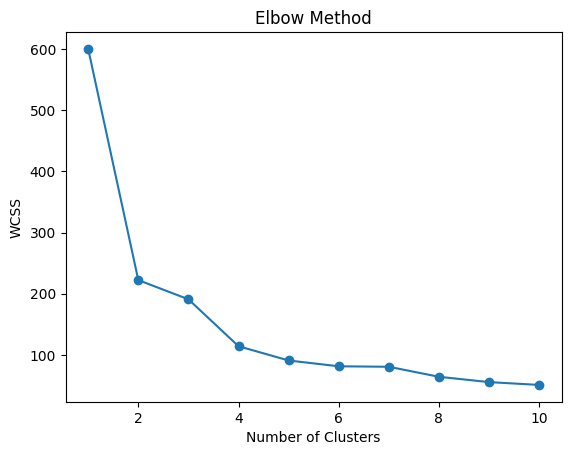

Best Parameters: {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 10}
Best Silhouette Score: 0.5817500491982808
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        1  
2        1  
3        1  
4        1  


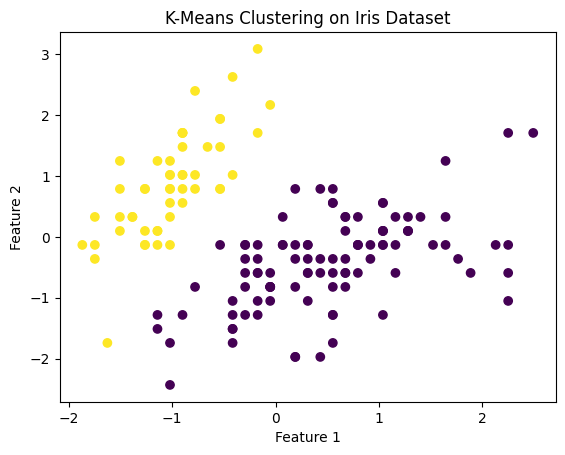

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid

# Load Iris Dataset
iris = load_iris()
X = iris.data

# Convert to dataframe
data = pd.DataFrame(X, columns=iris.feature_names)

# Show dataset
print(data.head())

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------
# Elbow Method
# -----------------------

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# -----------------------
# Hyperparameter Tuning
# -----------------------

param_grid = {
    'n_clusters': [2,3,4,5],
    'init': ['k-means++','random'],
    'n_init': [10,20],
    'max_iter': [200,300]
}

best_score = -1
best_params = None

for params in ParameterGrid(param_grid):

    model = KMeans(
        n_clusters=params['n_clusters'],
        init=params['init'],
        n_init=params['n_init'],
        max_iter=params['max_iter'],
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    if score > best_score:
        best_score = score
        best_params = params

print("Best Parameters:", best_params)
print("Best Silhouette Score:", best_score)

# -----------------------
# Train Final Model
# -----------------------

best_kmeans = KMeans(
    n_clusters=best_params['n_clusters'],
    init=best_params['init'],
    n_init=best_params['n_init'],
    max_iter=best_params['max_iter'],
    random_state=42
)

clusters = best_kmeans.fit_predict(X_scaled)

data['Cluster'] = clusters

print(data.head())

# -----------------------
# Cluster Visualization
# -----------------------

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering on Iris Dataset")
plt.show()

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


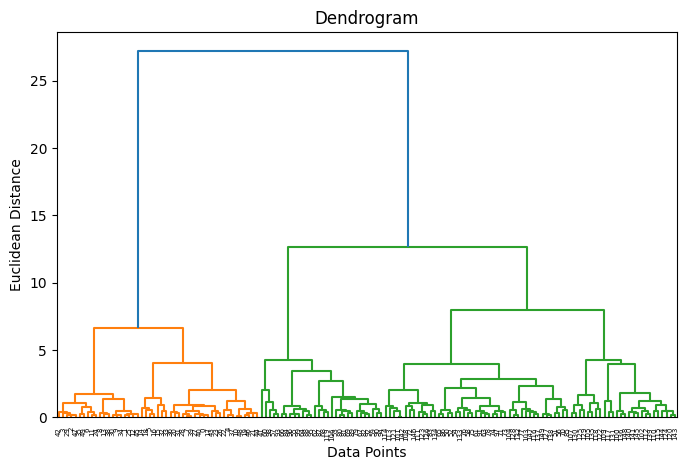

Best Parameters: {'linkage': 'average', 'n_clusters': 2}
Best Silhouette Score: 0.5817500491982808
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        1  
2        1  
3        1  
4        1  


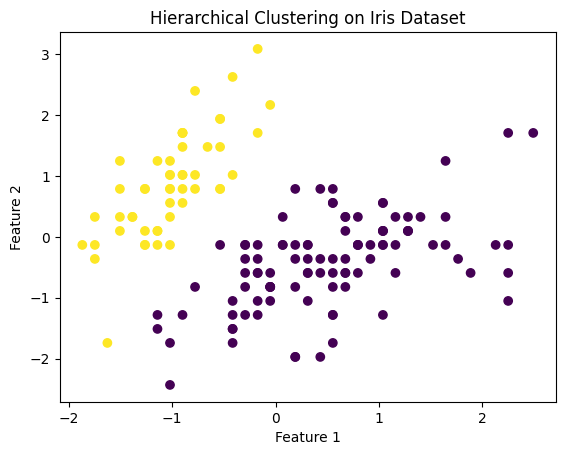

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid

import scipy.cluster.hierarchy as sch

# -----------------------------
# Load Dataset
# -----------------------------

iris = load_iris()
X = iris.data

data = pd.DataFrame(X, columns=iris.feature_names)

print(data.head())

# -----------------------------
# Feature Scaling
# -----------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Dendrogram
# -----------------------------

plt.figure(figsize=(8,5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

# -----------------------------
# Hyperparameter Tuning
# -----------------------------

param_grid = {
    'n_clusters': [2,3,4,5],
    'linkage': ['ward', 'complete', 'average']
}

best_score = -1
best_params = None

for params in ParameterGrid(param_grid):

    # Ward linkage only works with Euclidean
    if params['linkage'] == 'ward':
        model = AgglomerativeClustering(
            n_clusters=params['n_clusters'],
            linkage=params['linkage']
        )
    else:
        model = AgglomerativeClustering(
            n_clusters=params['n_clusters'],
            linkage=params['linkage'],
            metric='euclidean'
        )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    if score > best_score:
        best_score = score
        best_params = params

print("Best Parameters:", best_params)
print("Best Silhouette Score:", best_score)

# -----------------------------
# Train Final Model
# -----------------------------

final_model = AgglomerativeClustering(
    n_clusters=best_params['n_clusters'],
    linkage=best_params['linkage']
)

clusters = final_model.fit_predict(X_scaled)

data['Cluster'] = clusters

print(data.head())

# -----------------------------
# Cluster Visualization
# -----------------------------

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Hierarchical Clustering on Iris Dataset")
plt.show()